# FIAP — Dynamic Programming — Checkpoint 2 — Em Grupo
## [1] Identificação do grupo

| Nome completo | RA / RM |
|---------------|---------|
| Arthur Canaverde da Cruz | 563029 |
| Murilo Canestri | 564053 |

**Disciplina:** FIAP — Dynamic Programming  
**Checkpoint:** Checkpoint 2 — Grafos, recursão e memoização

---

## [2] Modelagem do grafo — teoria e código

Cada rede de metrô é modelada como **grafo não dirigido ponderado**:
- **Vértices:** estações.
- **Arestas:** trilhos com peso positivo (tempo de viagem em minutos, valor didático).
- **Justificativa (não dirigido):** em metrô urbano usual, o passageiro pode embarcar nos dois sentidos; o custo base é o mesmo (simetria). Se houvesse restrição de mão única, usaríamos grafo dirigido.

Com isso, o dicionário `grafo[s]` lista pares `(vizinho, peso)` para cada estação `s`.

**Requisitos atendidos:** ≥ 15 nós por cidade; mais de um caminho entre origem e destino (bifurcações).

In [10]:
# Imports e utilitários
from __future__ import annotations

import functools
import time
import tracemalloc
from typing import Dict, List, Tuple, Optional

Aresta = Tuple[str, float]
Grafo = Dict[str, List[Aresta]]


def grafo_nao_dirigido(arestas: List[Tuple[str, str, float]]) -> Grafo:
    """Monta lista de adjacência simétrica a partir de arestas (u, v, peso)."""
    g: Grafo = {}
    for u, v, w in arestas:
        g.setdefault(u, []).append((v, w))
        g.setdefault(v, []).append((u, w))
    return g


def checar_grafo(g: Grafo, min_nos: int = 15) -> None:
    assert len(g) >= min_nos, f"Esperado >= {min_nos} nós, obtido {len(g)}"
    for s, adjs in g.items():
        assert adjs, f"Estação sem vizinhos: {s}"


### Pequena rede **Beijing** (linhas 1, 2, 4 e 10 — subgrafo didático)
Origem: **Sihui East** → Destino: **Xizhimen** (≥ 7 estações de distância no enunciado; aqui há caminhos alternativos).

In [11]:
# Beijing — pesos em minutos (aproximação didática)
beijing_arestas = [
    ("Sihui East", "Sihui", 2),
    ("Sihui", "Shuangjing", 3),
    ("Shuangjing", "Guomao", 2),
    ("Guomao", "Jianguomen", 2),
    ("Jianguomen", "Dongdan", 2),
    ("Dongdan", "Wangfujing", 2),
    ("Wangfujing", "Tiananmen East", 2),
    ("Tiananmen East", "Tiananmen West", 2),
    ("Tiananmen West", "Xidan", 2),
    ("Xidan", "Fuxingmen", 3),
    ("Fuxingmen", "Muxidi", 3),
    ("Muxidi", "Gongzhufen", 2),
    ("Gongzhufen", "Wukesong", 3),
    ("Wukesong", "Pingguoyuan", 4),
    # ramal alternativo (mais de um caminho)
    ("Jianguomen", "Chaoyangmen", 2),
    ("Chaoyangmen", "Dongzhimen", 3),
    ("Dongzhimen", "Yonghegong", 3),
    ("Yonghegong", "Andingmen", 2),
    ("Andingmen", "Gulou Dajie", 2),
    ("Gulou Dajie", "Xinjiekou", 2),
    ("Xinjiekou", "Ping'anli", 2),
    ("Ping'anli", "Xisi", 2),
    ("Xisi", "Fuxingmen", 2),
    # ligação para Xizhimen (linha 2 / eixo oeste)
    ("Dongzhimen", "Dongsi Shitiao", 2),
    ("Dongsi Shitiao", "Chaoyangmen", 2),
    ("Xidan", "Xizhimen", 5),
    ("Fuxingmen", "Xizhimen", 6),
]

G_BEIJING = grafo_nao_dirigido(beijing_arestas)
checar_grafo(G_BEIJING)
print("Beijing — nós:", len(G_BEIJING))


Beijing — nós: 25


### Rede **BART** (San Francisco Bay Area)  
Origem: **Dublin/Pleasanton** → Destino: **Daly City**.

In [12]:
bart_arestas = [
    ("Dublin/Pleasanton", "West Dublin", 3),
    ("West Dublin", "Castro Valley", 4),
    ("Castro Valley", "Bay Fair", 3),
    ("Bay Fair", "San Leandro", 3),
    ("San Leandro", "Coliseum", 3),
    ("Coliseum", "Fruitvale", 2),
    ("Fruitvale", "Lake Merritt", 3),
    ("Lake Merritt", "West Oakland", 3),
    ("West Oakland", "Embarcadero", 5),
    ("Embarcadero", "Montgomery", 2),
    ("Montgomery", "Powell", 2),
    ("Powell", "Civic Center", 2),
    ("Civic Center", "16th Mission", 3),
    ("16th Mission", "24th Mission", 2),
    ("24th Mission", "Daly City", 5),
    # bifurcação: ramo via MacArthur
    ("Bay Fair", "Hayward", 3),
    ("Hayward", "South Hayward", 3),
    ("South Hayward", "Union City", 3),
    ("Union City", "Fremont", 4),
    ("Fremont", "MacArthur", 8),
    ("MacArthur", "19th Street Oakland", 3),
    ("19th Street Oakland", "12th Street Oakland", 2),
    ("12th Street Oakland", "West Oakland", 2),
]

G_BART = grafo_nao_dirigido(bart_arestas)
checar_grafo(G_BART)
print("BART — nós:", len(G_BART))


BART — nós: 23


### **São Paulo** (Metrô + trechos integrados — grafo didático)  
Origem: **Tucuruvi** → Destino: **Capão Redondo**, passando por ao menos uma estação de integração (**Sé** ou **Paraíso**).

In [13]:
sp_arestas = [
    ("Tucuruvi", "Parada Inglesa", 3),
    ("Parada Inglesa", "Jardim São Paulo", 3),
    ("Jardim São Paulo", "Santana", 3),
    ("Santana", "Carandiru", 2),
    ("Carandiru", "Portuguesa-Tietê", 3),
    ("Portuguesa-Tietê", "Armênia", 3),
    ("Armênia", "Tiradentes", 2),
    ("Tiradentes", "Luz", 3),
    ("Luz", "Sé", 2),
    ("Sé", "São Joaquim", 2),
    ("São Joaquim", "Paraíso", 2),
    ("Paraíso", "Ana Rosa", 2),
    ("Ana Rosa", "Vila Mariana", 2),
    ("Vila Mariana", "Santa Cruz", 3),
    ("Santa Cruz", "Praça da Árvore", 2),
    ("Praça da Árvore", "São Judas", 2),
    ("São Judas", "Conceição", 3),
    ("Conceição", "Jabaquara", 3),
    # ramal para linha sul / destino Capão Redondo (integrações modeladas como nós)
    ("Paraíso", "Santa Cecília", 4),
    ("Santa Cecília", "República", 3),
    ("República", "Sé", 2),
    ("Jabaquara", "São Paulo - Morumbi", 15),
    ("São Paulo - Morumbi", "Vila Andrade", 3),
    ("Vila Andrade", "Alto da Boa Vista", 3),
    ("Alto da Boa Vista", "Capão Redondo", 3),
    # segundo caminho via integração
    ("Sé", "Tiradentes", 2),
    ("Paraíso", "Vila Mariana", 3),
]

G_SP = grafo_nao_dirigido(sp_arestas)
checar_grafo(G_SP)
print("São Paulo — nós:", len(G_SP))


São Paulo — nós: 25


## [3] Implementação: recursão + memoização (menor custo) e backtracking (maior caminho simples)

### Menor custo (todos os caminhos simples)
Usamos recursão com estado `(origem, destino, horário, visitados)` e `functools.lru_cache` para memoizar subproblemas repetidos (mesmo subgrafo alcançável).

**Complexidade:** no pior caso, enumerar caminhos simples é exponencial em |V|; a memoização **reduz** chamadas quando o mesmo subproblema reaparece.

### Maior caminho simples
Backtracking: a cada passo marca nós visitados e desfaz ao retornar. Sem ciclos.

**Obs.:** Maior caminho simples é NP-difícil em grafos gerais; aqui os grafos são pequenos.

In [14]:
def fator_horario(hora: int) -> float:
    """Multiplicador sobre o peso da aresta (enunciado + faixa complementar).

    Faixas do PDF:
    - 5h–7h: 0.6
    - 7h–9h: 1.5
    - 9h–17h: 1.0
    - 17h–20h: 2.0
    Fora dessas faixas usamos 1.0 (neutro) — documentado para reproducibilidade.
    """
    if 5 <= hora < 7:
        return 0.6
    if 7 <= hora < 9:
        return 1.5
    if 9 <= hora < 17:
        return 1.0
    if 17 <= hora < 20:
        return 2.0
    return 1.0


def _menor_custo_core(grafo: Grafo, origem: str, destino: str, hora: int, visitados: frozenset) -> float:
    if origem == destino:
        return 0.0
    fator = fator_horario(hora)
    melhor = float("inf")
    novos_vis = visitados | {origem}
    for vizinho, peso in grafo[origem]:
        if vizinho not in visitados:
            sub = menor_custo_memo(vizinho, destino, hora, novos_vis)
            melhor = min(melhor, fator * peso + sub)
    return melhor


@functools.lru_cache(maxsize=None)
def menor_custo_memo(origem: str, destino: str, hora: int, visitados: frozenset) -> float:
    """Menor custo de `origem` a `destino` sem repetir vértices em `visitados`."""
    return _menor_custo_core(G_ATUAL, origem, destino, hora, visitados)


# Grafo atual usado pela função memoizada (troca-se antes das medições)
G_ATUAL: Grafo = G_SP


def menor_custo_sem_memo(grafo: Grafo, origem: str, destino: str, hora: int, visitados: Optional[frozenset] = None) -> float:
    """Mesma lógica, sem cache — para comparar tempo/memória."""
    if visitados is None:
        visitados = frozenset()
    if origem == destino:
        return 0.0
    fator = fator_horario(hora)
    melhor = float("inf")
    novos = visitados | {origem}
    for vizinho, peso in grafo[origem]:
        if vizinho not in visitados:
            sub = menor_custo_sem_memo(grafo, vizinho, destino, hora, novos)
            melhor = min(melhor, fator * peso + sub)
    return melhor


def reconstruir_caminho_menor(grafo: Grafo, origem: str, destino: str, hora: int) -> Tuple[float, List[str]]:
    """GREEDY usando custos já memoizados globalmente na G_ATUAL configurada igual a `grafo`."""
    global G_ATUAL
    G_ATUAL = grafo
    menor_custo_memo.cache_clear()
    custo_tot = menor_custo_memo(origem, destino, hora, frozenset())
    caminho = [origem]
    visitados_loc = frozenset()
    atual = origem
    while atual != destino:
        visitados_loc = visitados_loc | {atual}
        fator = fator_horario(hora)
        melhor_v, melhor_c = None, float("inf")
        for viz, peso in grafo[atual]:
            if viz not in visitados_loc:
                c = fator * peso + menor_custo_memo(viz, destino, hora, visitados_loc)
                if c < melhor_c:
                    melhor_c, melhor_v = c, viz
        if melhor_v is None:
            break
        atual = melhor_v
        caminho.append(atual)
    return custo_tot, caminho


def maior_caminho_simples_bt(grafo: Grafo, origem: str, destino: str, hora: int) -> Tuple[float, List[str]]:
    """Maior custo dentre caminhos simples (backtracking)."""
    fator = fator_horario(hora)
    melhor_custo = -1.0
    melhor_caminho: List[str] = []

    def bt(atual: str, visitados: set, acc: float, caminho: List[str]) -> None:
        nonlocal melhor_custo, melhor_caminho
        if atual == destino:
            if acc > melhor_custo:
                melhor_custo, melhor_caminho = acc, list(caminho)
            return
        for viz, peso in grafo[atual]:
            if viz not in visitados:
                visitados.add(viz)
                caminho.append(viz)
                bt(viz, visitados, acc + fator * peso, caminho)
                caminho.pop()
                visitados.remove(viz)

    visitados = {origem}
    bt(origem, visitados, 0.0, [origem])
    if melhor_custo < 0:
        return float("-inf"), []
    return melhor_custo, melhor_caminho


def caminho_sp_com_integracao(
    grafo: Grafo, origem: str, destino: str, hora: int, integracoes: set
) -> Tuple[Optional[float], Optional[List[str]]]:
    """Restringe a caminhos que passam por ao menos um nó em `integracoes`."""
    fator = fator_horario(hora)
    melhor: Optional[float] = None
    melhor_p: Optional[List[str]] = None

    def bt(atual: str, visitados: set, acc: float, path: List[str], passou_int: bool) -> None:
        nonlocal melhor, melhor_p
        if atual == destino and passou_int:
            if melhor is None or acc < melhor:
                melhor, melhor_p = acc, list(path)
            return
        for viz, peso in grafo[atual]:
            if viz not in visitados:
                visitados.add(viz)
                path.append(viz)
                bt(viz, visitados, acc + fator * peso, path, passou_int or (viz in integracoes))
                path.pop()
                visitados.remove(viz)

    v = {origem}
    bt(origem, v, 0.0, [origem], origem in integracoes)
    return melhor, melhor_p

print("Funções de busca definidas.")


Funções de busca definidas.


## [4] Fatores de horário

O usuário informa a **hora inteira** de partida (0–23). O fator multiplica cada aresta **antes** da busca (como no enunciado).

In [15]:
def demo_fatores():
    for h in [6, 8, 12, 18, 22]:
        print(f"Hora {h:02d}h -> fator {fator_horario(h)}")

demo_fatores()


Hora 06h -> fator 0.6
Hora 08h -> fator 1.5
Hora 12h -> fator 1.0
Hora 18h -> fator 2.0
Hora 22h -> fator 1.0


## [5] Resultados: Beijing, San Francisco, São Paulo

In [16]:
def relatorio_cidade(nome: str, grafo: Grafo, o: str, d: str, hora: int, sp_integracao: Optional[set] = None):
    global G_ATUAL
    G_ATUAL = grafo
    menor_custo_memo.cache_clear()
    print(f"\n=== {nome} | partida {hora}h ===")
    if sp_integracao:
        cmin, pmin = caminho_sp_com_integracao(grafo, o, d, hora, sp_integracao)
        print("Menor custo (com integração obrigatória):", cmin)
        print("Caminho:", " -> ".join(pmin) if pmin else None)
    else:
        cmin, pmin = reconstruir_caminho_menor(grafo, o, d, hora)
        print("Menor custo (ponderado):", round(cmin, 2))
        print("Caminho (exemplo ótimo greedy pós-memo):", " -> ".join(pmin))
    cmax, pmax = maior_caminho_simples_bt(grafo, o, d, hora)
    print("Maior caminho simples (custo):", round(cmax, 2))
    print("Caminho:", " -> ".join(pmax))

# Horário de pico da tarde (exemplo)
H = 18

relatorio_cidade("Beijing", G_BEIJING, "Sihui East", "Xizhimen", H)
relatorio_cidade("San Francisco (BART)", G_BART, "Dublin/Pleasanton", "Daly City", H)
relatorio_cidade(
    "São Paulo",
    G_SP,
    "Tucuruvi",
    "Capão Redondo",
    H,
    sp_integracao={"Sé", "Paraíso"},
)



=== Beijing | partida 18h ===
Menor custo (ponderado): 48.0
Caminho (exemplo ótimo greedy pós-memo): Sihui East -> Sihui -> Shuangjing -> Guomao -> Jianguomen -> Dongdan -> Wangfujing -> Tiananmen East -> Tiananmen West -> Xidan -> Xizhimen
Maior caminho simples (custo): 76.0
Caminho: Sihui East -> Sihui -> Shuangjing -> Guomao -> Jianguomen -> Chaoyangmen -> Dongsi Shitiao -> Dongzhimen -> Yonghegong -> Andingmen -> Gulou Dajie -> Xinjiekou -> Ping'anli -> Xisi -> Fuxingmen -> Xidan -> Xizhimen

=== San Francisco (BART) | partida 18h ===
Menor custo (ponderado): 90.0
Caminho (exemplo ótimo greedy pós-memo): Dublin/Pleasanton -> West Dublin -> Castro Valley -> Bay Fair -> San Leandro -> Coliseum -> Fruitvale -> Lake Merritt -> West Oakland -> Embarcadero -> Montgomery -> Powell -> Civic Center -> 16th Mission -> 24th Mission -> Daly City
Maior caminho simples (custo): 118.0
Caminho: Dublin/Pleasanton -> West Dublin -> Castro Valley -> Bay Fair -> Hayward -> South Hayward -> Union City

## [6] Análise de desempenho (tempo + memória)

Medimos `time.perf_counter()` e `tracemalloc` com e **sem** `lru_cache` na função de menor custo.

A figura seguinte tem **dois** gráficos (dois eixos, um por cima do outro): **tempo** e **pico de memória** — não há um terceiro gráfico.

**Observação (São Paulo):** enumerar todos os caminhos simples **sem memoização** entre `Tucuruvi` e `Capão Redondo` teria custo explosivo. Por isso, para **sem memo** usamos o par mais curto `Tucuruvi → Carandiru`, enquanto **com memo** mantém o par longo completo. Em **São Paulo**, o gráfico de **tempo** portanto **não** compara o mesmo problema nos dois casos; já **memória** e os tempos de Beijing/BART são comparáveis no mesmo par origem–destino. Beijing e BART usam sempre o mesmo par em ambas as barras.

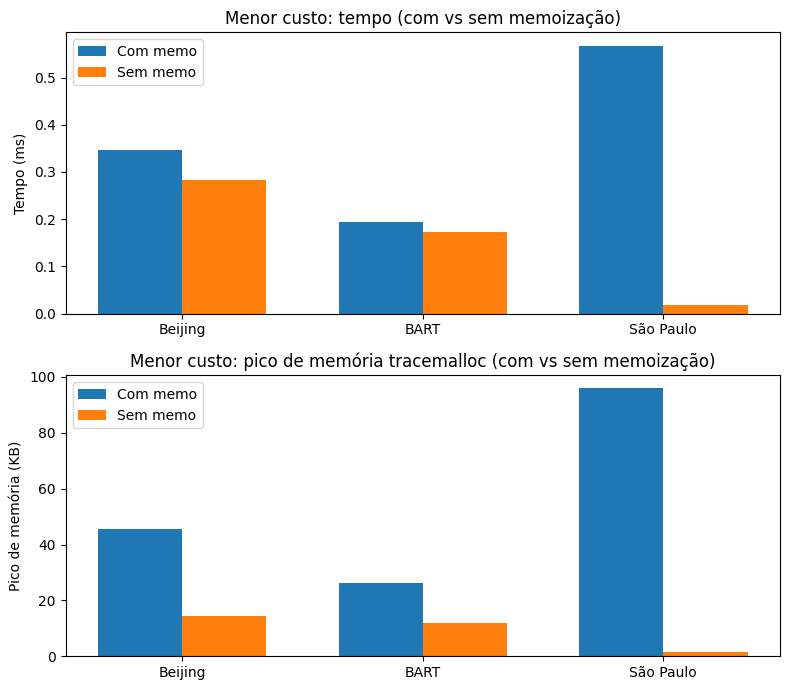

In [17]:
import pandas as pd


def medir_menor_custo(grafo: Grafo, origem: str, destino: str, hora: int, com_memo: bool):
    global G_ATUAL
    G_ATUAL = grafo
    menor_custo_memo.cache_clear()
    tracemalloc.start()
    t0 = time.perf_counter()
    if com_memo:
        _ = menor_custo_memo(origem, destino, hora, frozenset())
    else:
        _ = menor_custo_sem_memo(grafo, origem, destino, hora, frozenset())
    t1 = time.perf_counter()
    cur, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return (t1 - t0) * 1000, peak / 1024  # ms, KB


def tabela_desempenho(hora: int = 10):
    linhas = []
    casos = [
        ("Beijing", G_BEIJING, "Sihui East", "Xizhimen", "Sihui East", "Xizhimen"),
        ("BART", G_BART, "Dublin/Pleasanton", "Daly City", "Dublin/Pleasanton", "Daly City"),
        # com memo: percurso longo; sem memo: par mais curto (evita explosão combinatória)
        ("São Paulo", G_SP, "Tucuruvi", "Capão Redondo", "Tucuruvi", "Carandiru"),
    ]
    for nome, g, o_com, d_com, o_sem, d_sem in casos:
        t_com, kb_com = medir_menor_custo(g, o_com, d_com, hora, True)
        t_sem, kb_sem = medir_menor_custo(g, o_sem, d_sem, hora, False)
        linhas.append({
            "Cidade": nome,
            "Com memo — tempo (ms)": round(t_com, 4),
            "Sem memo — tempo (ms)": round(t_sem, 4),
            "Com memo — pico mem (KB)": round(kb_com, 2),
            "Sem memo — pico mem (KB)": round(kb_sem, 2),
        })
    df = pd.DataFrame(linhas)
    return df


df_perf = tabela_desempenho(10)

try:
    import matplotlib.pyplot as plt
    fig, (ax_t, ax_m) = plt.subplots(2, 1, figsize=(8, 7))
    x = list(range(len(df_perf)))
    w = 0.35
    cidades = df_perf["Cidade"].tolist()

    ax_t.bar([i - w / 2 for i in x], df_perf["Com memo — tempo (ms)"], width=w, label="Com memo")
    ax_t.bar([i + w / 2 for i in x], df_perf["Sem memo — tempo (ms)"], width=w, label="Sem memo")
    ax_t.set_xticks(x)
    ax_t.set_xticklabels(cidades)
    ax_t.set_ylabel("Tempo (ms)")
    ax_t.set_title("Menor custo: tempo (com vs sem memoização)")
    ax_t.legend()

    ax_m.bar([i - w / 2 for i in x], df_perf["Com memo — pico mem (KB)"], width=w, label="Com memo")
    ax_m.bar([i + w / 2 for i in x], df_perf["Sem memo — pico mem (KB)"], width=w, label="Sem memo")
    ax_m.set_xticks(x)
    ax_m.set_xticklabels(cidades)
    ax_m.set_ylabel("Pico de memória (KB)")
    ax_m.set_title("Menor custo: pico de memória tracemalloc (com vs sem memoização)")
    ax_m.legend()

    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Matplotlib indisponível ou erro no gráfico:", e)


### Complexidade (discussão breve)
- **Menor custo (recursão):** sem memo, no pior caso proporcional ao número de caminhos simples (exponencial em |V| em grafos densos). Com `lru_cache`, estados `(vértice atual, destino, visitados)` repetidos são O(1) na prática após o primeiro cálculo — ganho depende da estrutura do grafo.
- **Maior caminho simples:** backtracking explora O(caminhos simples) no pior caso.
- **Espaço:** memoização armazena um valor por estado alcançado; `tracemalloc` mede pico alocado durante a execução.

## [7] Visualização com Folium + conclusões

Mapas **aproximados** (coordenadas didáticas) para as **três cidades**. Marcadores: vermelho = estações da rota de menor custo; azul = outras. **Linha verde** = percurso ótimo à hora indicada (o fator horário entra no custo do algoritmo). Em **São Paulo**, o enunciado exige passagem por integração na análise da secção **[5]**; no mapa abaixo mostramos o menor custo **no grafo completo** (sem essa restrição extra), para comparar visualmente com as outras cidades.

- **Beijing:** Sihui East → Xizhimen  
- **BART (San Francisco Bay Area):** Dublin/Pleasanton → Daly City  
- **São Paulo:** Tucuruvi → Capão Redondo (menor custo global no grafo; a sec. [5] pode usar restrição de integração **Sé**/ **Paraíso**)

**Nota:** após **reiniciar o kernel**, corre **Run All** até à secção [3] antes desta célula. No GitHub, se o iframe não for interativo, abre no Jupyter local ou usa `m.save("mapa.html")`.

In [18]:
import folium

if "reconstruir_caminho_menor" not in globals() or "menor_custo_memo" not in globals():
    raise RuntimeError(
        "Corre primeiro as células de cima (secção [2] + [3] — funções de busca), "
        "ou usa Restart Kernel e Run All."
    )


def _obtem_grafo_sp() -> Grafo:
    """Usa G_SP da célula São Paulo; se ainda não existir, monta o mesmo grafo aqui."""
    g_sp = globals().get("G_SP")
    if g_sp is not None:
        return g_sp
    sp_arestas = [
        ("Tucuruvi", "Parada Inglesa", 3),
        ("Parada Inglesa", "Jardim São Paulo", 3),
        ("Jardim São Paulo", "Santana", 3),
        ("Santana", "Carandiru", 2),
        ("Carandiru", "Portuguesa-Tietê", 3),
        ("Portuguesa-Tietê", "Armênia", 3),
        ("Armênia", "Tiradentes", 2),
        ("Tiradentes", "Luz", 3),
        ("Luz", "Sé", 2),
        ("Sé", "São Joaquim", 2),
        ("São Joaquim", "Paraíso", 2),
        ("Paraíso", "Ana Rosa", 2),
        ("Ana Rosa", "Vila Mariana", 2),
        ("Vila Mariana", "Santa Cruz", 3),
        ("Santa Cruz", "Praça da Árvore", 2),
        ("Praça da Árvore", "São Judas", 2),
        ("São Judas", "Conceição", 3),
        ("Conceição", "Jabaquara", 3),
        ("Paraíso", "Santa Cecília", 4),
        ("Santa Cecília", "República", 3),
        ("República", "Sé", 2),
        ("Jabaquara", "São Paulo - Morumbi", 15),
        ("São Paulo - Morumbi", "Vila Andrade", 3),
        ("Vila Andrade", "Alto da Boa Vista", 3),
        ("Alto da Boa Vista", "Capão Redondo", 3),
        ("Sé", "Tiradentes", 2),
        ("Paraíso", "Vila Mariana", 3),
    ]
    g = grafo_nao_dirigido(sp_arestas)
    checar_grafo(g)
    return g


# Coordenadas aproximadas (lat, lon) — didático
coords_sp = {
    "Tucuruvi": (-23.5489, -46.6044),
    "Parada Inglesa": (-23.5452, -46.6023),
    "Jardim São Paulo": (-23.5415, -46.5974),
    "Santana": (-23.5156, -46.6279),
    "Carandiru": (-23.5122, -46.6286),
    "Portuguesa-Tietê": (-23.5085, -46.6274),
    "Armênia": (-23.5034, -46.6272),
    "Tiradentes": (-23.4985, -46.6272),
    "Luz": (-23.5351, -46.6340),
    "Sé": (-23.5505, -46.6342),
    "São Joaquim": (-23.5565, -46.6292),
    "Paraíso": (-23.5604, -46.6275),
    "Ana Rosa": (-23.5653, -46.6275),
    "Vila Mariana": (-23.5712, -46.6274),
    "Santa Cruz": (-23.5794, -46.6272),
    "Praça da Árvore": (-23.5856, -46.6270),
    "São Judas": (-23.5915, -46.6270),
    "Conceição": (-23.5975, -46.6270),
    "Jabaquara": (-23.6035, -46.6270),
    "Santa Cecília": (-23.5474, -46.6594),
    "República": (-23.5395, -46.6594),
    "São Paulo - Morumbi": (-23.6200, -46.6980),
    "Vila Andrade": (-23.6320, -46.7380),
    "Alto da Boa Vista": (-23.6420, -46.7580),
    "Capão Redondo": (-23.6560, -46.7660),
}

# Beijing — coordenadas didáticas (~OSM)
coords_bj = {
    "Sihui East": (39.915, 116.515),
    "Sihui": (39.914, 116.505),
    "Shuangjing": (39.912, 116.475),
    "Guomao": (39.908, 116.459),
    "Jianguomen": (39.908, 116.436),
    "Dongdan": (39.908, 116.417),
    "Wangfujing": (39.908, 116.411),
    "Tiananmen East": (39.905, 116.401),
    "Tiananmen West": (39.905, 116.391),
    "Xidan": (39.907, 116.373),
    "Fuxingmen": (39.907, 116.356),
    "Muxidi": (39.907, 116.335),
    "Gongzhufen": (39.907, 116.318),
    "Wukesong": (39.914, 116.295),
    "Pingguoyuan": (39.926, 116.277),
    "Chaoyangmen": (39.924, 116.434),
    "Dongzhimen": (39.941, 116.434),
    "Yonghegong": (39.949, 116.416),
    "Andingmen": (39.949, 116.407),
    "Gulou Dajie": (39.949, 116.395),
    "Xinjiekou": (39.949, 116.378),
    "Ping'anli": (39.939, 116.372),
    "Xisi": (39.925, 116.365),
    "Dongsi Shitiao": (39.933, 116.428),
    "Xizhimen": (39.940, 116.355),
}

# BART — coordenadas didáticas (~OSM)
coords_bart = {
    "Dublin/Pleasanton": (37.701, -121.928),
    "West Dublin": (37.700, -121.934),
    "Castro Valley": (37.691, -122.075),
    "Bay Fair": (37.685, -122.127),
    "San Leandro": (37.725, -122.161),
    "Coliseum": (37.753, -122.198),
    "Fruitvale": (37.775, -122.224),
    "Lake Merritt": (37.813, -122.265),
    "West Oakland": (37.805, -122.297),
    "Embarcadero": (37.793, -122.396),
    "Montgomery": (37.789, -122.401),
    "Powell": (37.784, -122.407),
    "Civic Center": (37.779, -122.414),
    "16th Mission": (37.765, -122.419),
    "24th Mission": (37.752, -122.418),
    "Daly City": (37.706, -122.469),
    "Hayward": (37.670, -122.088),
    "South Hayward": (37.634, -122.057),
    "Union City": (37.596, -122.018),
    "Fremont": (37.558, -121.986),
    "MacArthur": (37.829, -122.267),
    "19th Street Oakland": (37.808, -122.268),
    "12th Street Oakland": (37.803, -122.272),
}


def mapa_folium_menor_custo(
    grafo: Grafo,
    coords: Dict[str, Tuple[float, float]],
    origem: str,
    destino: str,
    hora: int,
    zoom_start: int = 11,
) -> Tuple[folium.Map, List[str]]:
    global G_ATUAL
    G_ATUAL = grafo
    menor_custo_memo.cache_clear()
    _, caminho = reconstruir_caminho_menor(grafo, origem, destino, hora)
    la0, lo0 = coords.get(origem, next(iter(coords.values())))
    m = folium.Map(location=[la0, lo0], zoom_start=zoom_start, tiles="OpenStreetMap")
    set_c = set(caminho)
    for nome, (la, lo) in coords.items():
        cor = "red" if nome in set_c else "blue"
        folium.CircleMarker([la, lo], radius=5, color=cor, fill=True, popup=nome).add_to(m)
    pts = [[coords[n][0], coords[n][1]] for n in caminho if n in coords]
    if len(pts) >= 2:
        folium.PolyLine(pts, color="green", weight=5, opacity=0.85, popup="Menor custo").add_to(m)
    return m, caminho


def mapa_folium_sp(hora: int = 12) -> Tuple[folium.Map, List[str]]:
    g = _obtem_grafo_sp()
    return mapa_folium_menor_custo(g, coords_sp, "Tucuruvi", "Capão Redondo", hora, zoom_start=11)


if "G_BEIJING" not in globals() or "G_BART" not in globals():
    raise RuntimeError("Corre as células da secção [2] (G_BEIJING, G_BART) antes desta.")

HORA_MAPA = 18
m_bj, cam_bj = mapa_folium_menor_custo(G_BEIJING, coords_bj, "Sihui East", "Xizhimen", HORA_MAPA, zoom_start=10)
m_sf, cam_sf = mapa_folium_menor_custo(
    G_BART, coords_bart, "Dublin/Pleasanton", "Daly City", HORA_MAPA, zoom_start=9
)
m_sp, cam_sp = mapa_folium_sp(HORA_MAPA)

from IPython.display import display

print("Beijing (menor custo):", " -> ".join(cam_bj))
print("BART:", " -> ".join(cam_sf))
print("São Paulo:", " -> ".join(cam_sp))
display(m_bj)
display(m_sf)
display(m_sp)


Beijing (menor custo): Sihui East -> Sihui -> Shuangjing -> Guomao -> Jianguomen -> Dongdan -> Wangfujing -> Tiananmen East -> Tiananmen West -> Xidan -> Xizhimen
BART: Dublin/Pleasanton -> West Dublin -> Castro Valley -> Bay Fair -> San Leandro -> Coliseum -> Fruitvale -> Lake Merritt -> West Oakland -> Embarcadero -> Montgomery -> Powell -> Civic Center -> 16th Mission -> 24th Mission -> Daly City
São Paulo: Tucuruvi -> Parada Inglesa -> Jardim São Paulo -> Santana -> Carandiru -> Portuguesa-Tietê -> Armênia -> Tiradentes -> Sé -> São Joaquim -> Paraíso -> Vila Mariana -> Santa Cruz -> Praça da Árvore -> São Judas -> Conceição -> Jabaquara -> São Paulo - Morumbi -> Vila Andrade -> Alto da Boa Vista -> Capão Redondo
